In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
x=pd.read_csv(r"C:\Users\shivam parihari\Downloads\archive (3)\ford.csv")

In [3]:
x.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
x.shape

(17966, 9)

In [5]:
x.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [6]:
x.dtypes

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [7]:
for i in x:
    print(f"{i}:\n {x[i].unique()}")

model:
 [' Fiesta' ' Focus' ' Puma' ' Kuga' ' EcoSport' ' C-MAX' ' Mondeo' ' Ka+'
 ' Tourneo Custom' ' S-MAX' ' B-MAX' ' Edge' ' Tourneo Connect'
 ' Grand C-MAX' ' KA' ' Galaxy' ' Mustang' ' Grand Tourneo Connect'
 ' Fusion' ' Ranger' ' Streetka' ' Escort' ' Transit Tourneo' 'Focus']
year:
 [2017 2018 2019 2015 2014 2016 2013 2020 2012 2008 2010 2009 2011 1998
 2007 2005 2006 2002 2003 1996 2004 2000 2060]
price:
 [12000 14000 13000 ... 12849 16249 18122]
transmission:
 ['Automatic' 'Manual' 'Semi-Auto']
mileage:
 [15944  9083 12456 ... 31348  7010  5007]
fuelType:
 ['Petrol' 'Diesel' 'Hybrid' 'Electric' 'Other']
tax:
 [150 145   0  20 160 125  30 235 240 200 165 140 570 205 260 580 135 265
 300 195 120 555 325 155 270 115 110 190 210 185 330 230 220 305 290  22]
mpg:
 [ 57.7  40.3  48.7  47.9  50.4  54.3  42.2  61.4  56.5  65.7  58.9  64.2
  38.2  62.8  55.4  41.5  68.9  78.5  60.1  53.3  39.2  74.3  43.5  31.7
  57.6  44.1  49.6  76.4  34.4  44.8  36.7  67.3  52.3  51.4  70.6  46.3
 

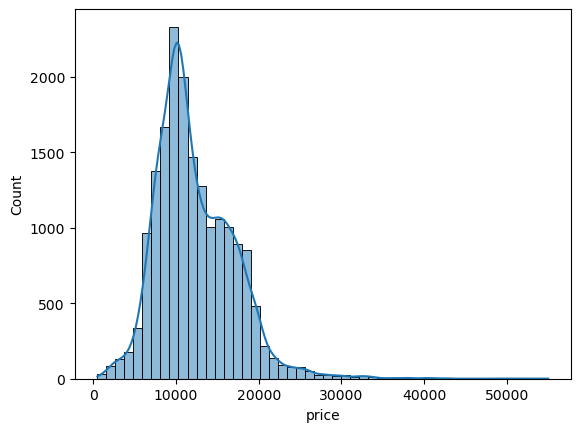

In [8]:
sns.histplot(x['price'],bins=50,kde=True)
plt.show()

In [9]:
c=x.corr(numeric_only=True)

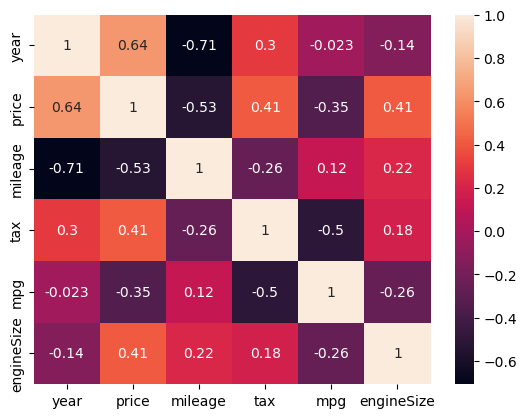

In [10]:
sns.heatmap(c,annot=True)
plt.show()

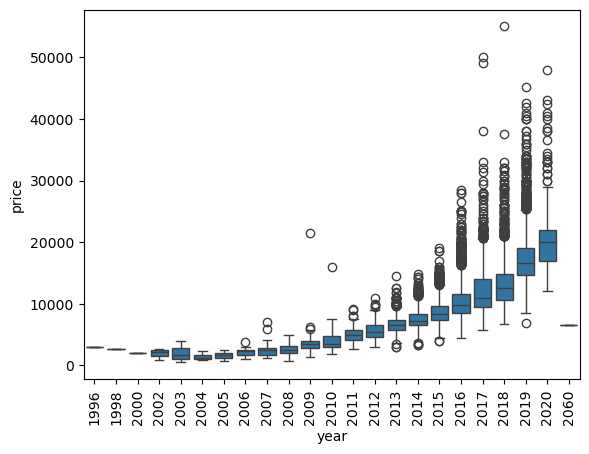

In [11]:
sns.boxplot(data=x,x='year',y='price')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='mileage', ylabel='mpg'>

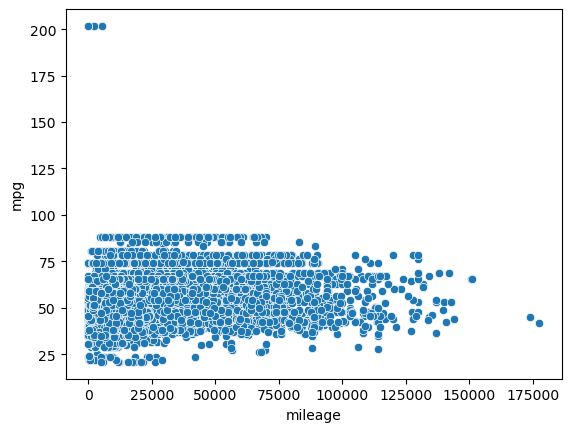

In [12]:
sns.scatterplot(x='mileage',y='mpg',data=x)

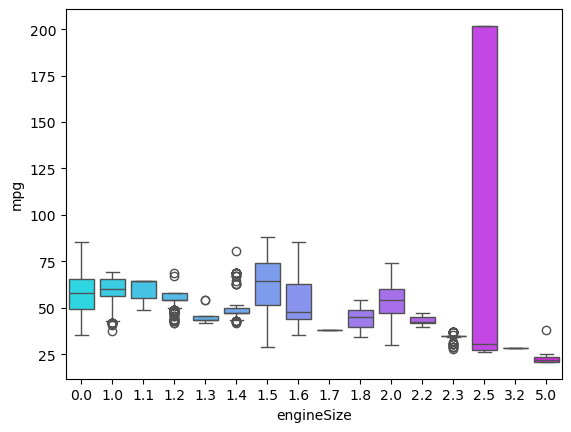

In [13]:
sns.boxplot(x='engineSize',y='mpg',data=x,palette='cool')
plt.show()


<Axes: xlabel='transmission', ylabel='price'>

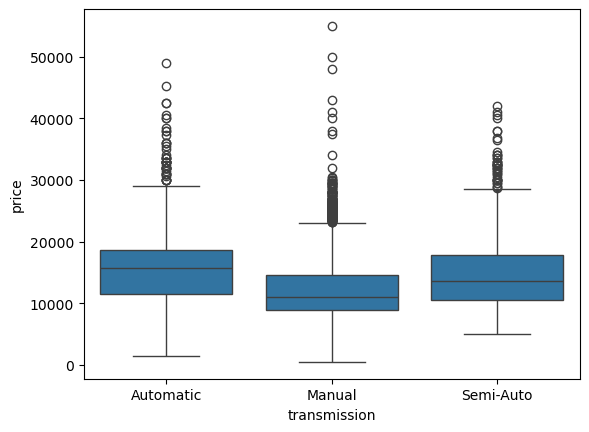

In [14]:
sns.boxplot(data=x,x='transmission',y='price')


<Axes: xlabel='transmission', ylabel='price'>

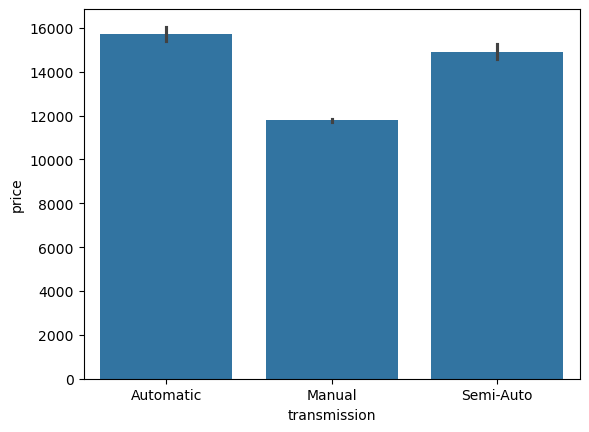

In [15]:
sns.barplot(data=x,x='transmission',y='price')

<Axes: xlabel='fuelType', ylabel='price'>

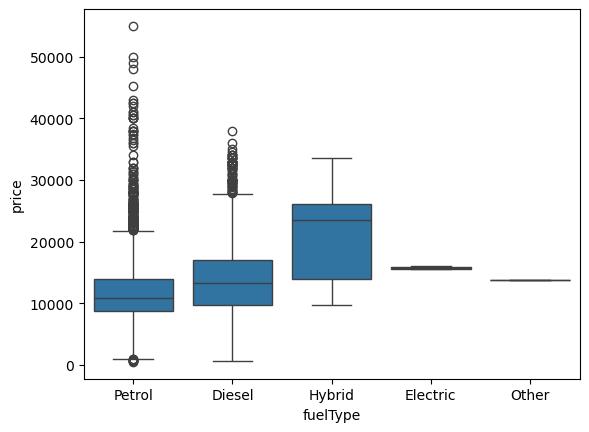

In [16]:
sns.boxplot(data=x,x='fuelType',y='price')


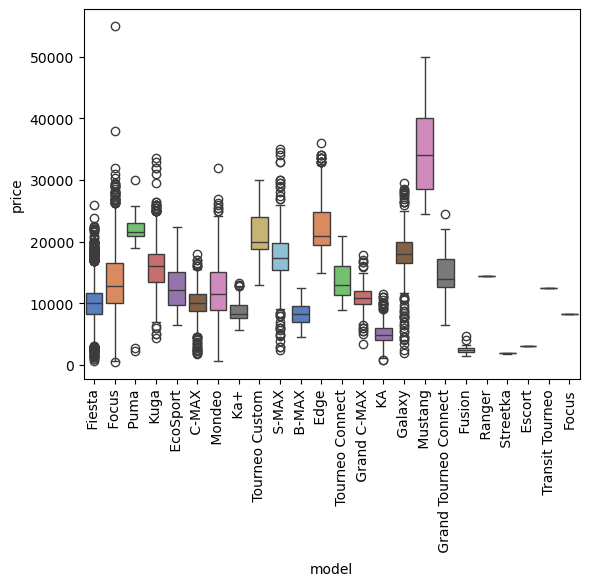

In [17]:
sns.boxplot(x='model',y='price',data=x,palette='muted')

plt.xticks(rotation=90)
plt.show()

In [18]:
x = pd.get_dummies(x, columns=['model', 'transmission', 'fuelType'], drop_first=True)


In [19]:
ip=x.drop(columns='price')
ip.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [20]:
op=x.price
op

0        12000
1        14000
2        13000
3        17500
4        16500
         ...  
17961     8999
17962     7499
17963     9999
17964     8299
17965     8299
Name: price, Length: 17966, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(ip,op,test_size=0.33)
xtrain


,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
9056,2020,16,145,65.7,2.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9035,2017,14661,160,44.1,1.6,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1095,2016,28805,125,54.3,1.2,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
11735,2018,13921,150,65.7,1.0,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
16517,2016,65000,0,65.7,1.0,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17196,2018,2210,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
943,2019,6157,145,54.3,1.5,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9756,2018,5315,145,51.4,1.0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
10889,2014,41633,30,56.5,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrain= sc.fit_transform(xtrain)
xtest = sc.transform(xtest)
# test data pe fit transform nahi lagta


In [23]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(xtrain,ytrain)

LinearRegression()

In [24]:
pred=lr.predict(xtest)
pred

array([10512.60884568, 15759.66938268, 18356.61861583, ...,
        5589.96334078, 10206.71258005, 13756.88561328])

In [25]:
# to find accuracy we need mean squared error and r2 score
# mean sq error=  sum[y(original)-y(prediction)]^2/n
from sklearn.metrics import mean_squared_error
error=mean_squared_error(pred,ytest)
error


3324125.9732221076

In [26]:
from sklearn.metrics import r2_score
acc = r2_score(ytest, pred)

acc

0.8541266345081564

In [27]:
e=pd.DataFrame({'y-test':list(ytest),'prediction':list(pred)})
e


,y-test,prediction
0,9992,10512.608846
1,16000,15759.669383
2,19298,18356.618616
3,12998,12746.950508
4,11330,12970.683958
...,...,...
5924,10298,9155.476716
5925,8999,9751.448563
5926,6191,5589.963341
5927,9498,10206.712580


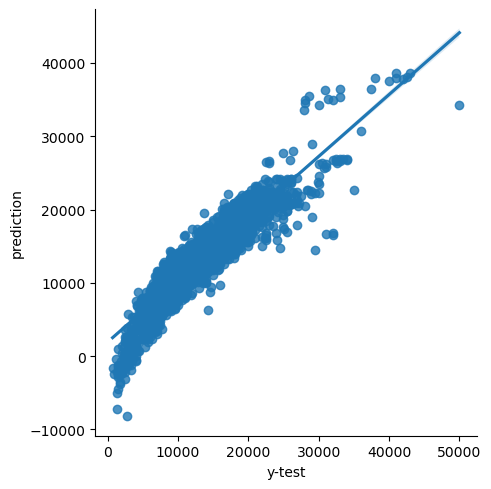

In [28]:
sns.lmplot(x='y-test',y='prediction',data=e)
plt.show()